# Multi-Agent Sales Workflow with Agentic Governance

This notebook demonstrates real-time node-level evaluation using watsonx.governance AgenticEvaluator.

## Key Features
- Node-level evaluation with decorators
- Real-time metrics during workflow execution
- Graph visualization
- Comprehensive metrics DataFrame with costs, latency, and quality scores

## Setup

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import uuid
from typing import TypedDict
from agents.supervisory_agent import SupervisoryAgent
from agents.contract_agent import ContractAgent
from agents.research_agent import research_partner
from agents.matching_agent import MatchingAgent
from agents.action_agent import ActionAgent

load_dotenv()

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Initialize watsonx.governance

In [2]:
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.config import AgenticAIConfiguration
from ibm_watsonx_gov.config.agentic_ai_configuration import TracingConfiguration
from ibm_watsonx_gov.metrics import FaithfulnessMetric, ContextRelevanceMetric
from ibm_watsonx_gov.entities.foundation_model import WxAIFoundationModel
from ibm_watsonx_gov.entities.llm_judge import LLMJudge

PROJECT_ID = os.getenv("WATSONX_PROJECT_ID")
REGION = os.getenv("WATSONX_REGION")

# Initialize LLM Judge
llm_judge = LLMJudge(
    model=WxAIFoundationModel(
        model_id="meta-llama/llama-3-3-70b-instruct",
        project_id=PROJECT_ID,
        region=REGION
    )
)

# Initialize Agentic Evaluator
evaluator = AgenticEvaluator(
    tracing_configuration=TracingConfiguration(
        project_id=PROJECT_ID,
        enable_metrics=True
    )
)

print("[SUCCESS] watsonx.governance initialized")

ERROR:root:Error initializing LangChain instrumentor: cannot import name 'ContextOverflowError' from 'langchain_core.exceptions' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/langchain_core/exceptions.py)


Custom exporter logging initialized. App name: Noas_ipykernel_launcher
Traceloop exporting traces to a custom exporter

Metrics are disabled
[SUCCESS] watsonx.governance initialized


## Initialize LLM

In [3]:
# Set WATSONX_APIKEY in environment if not already set
if 'WATSONX_APIKEY' not in os.environ:
    os.environ['WATSONX_APIKEY'] = os.getenv('WATSONX_APIKEY', '')

print(f"API Key set: {'Yes' if os.environ.get('WATSONX_APIKEY') else 'No'}")
print(f"Project ID: {PROJECT_ID[:8]}..." if PROJECT_ID else "Project ID not set")

API Key set: Yes
Project ID: ce21bf42...


In [4]:
from langchain_ibm import ChatWatsonx

# Initialize ChatWatsonx (uses WATSONX_APIKEY from environment)
parameters = {
    "temperature": 0.3,
    "max_tokens": 500,
}

chat_model = ChatWatsonx(
    model_id="meta-llama/llama-4-maverick-17b-128e-instruct-fp8",
    url="https://us-south.ml.cloud.ibm.com",
    project_id=PROJECT_ID,
    params=parameters,
)

print("[SUCCESS] LLM initialized")

[SUCCESS] LLM initialized


## Initialize Agents

In [5]:
# Initialize the Supervisory Agent with governance components
print("Initializing Supervisory Agent...")
supervisor = SupervisoryAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID,
    evaluator=evaluator,
    llm_judge=llm_judge
)

# Build the supervisor's internal graph (which has decorators)
supervisor.build_agent()
print("✓ Supervisory Agent ready (with governance)\n")

# Initialize Contract Agent
print("Initializing Contract Agent...")
contract_agent = ContractAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Contract Agent ready\n")

# Note: Research functionality uses research_partner function directly
print("✓ Research function imported\n")

# Initialize Matching Agent
print("Initializing Matching Agent...")
matching_agent = MatchingAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Matching Agent ready\n")

# Initialize Action Agent
print("Initializing Action Agent...")
action_agent = ActionAgent(
    apikey=os.getenv("WATSONX_APIKEY"),
    project_id=PROJECT_ID
)
print("✓ Action Agent ready\n")

Initializing Supervisory Agent...

[DEBUG DECORATOR] Applying decorators - evaluator: True, llm_judge: True
[DEBUG DECORATOR] CONTRACT NODE - Applying evaluate_retrieval_quality decorator
[DEBUG DECORATOR] CONTRACT CONFIG - input_fields: ['seller_query', 'partner_name']
[DEBUG DECORATOR] CONTRACT CONFIG - context_fields: ['contract_summary']
[DEBUG DECORATOR] CONTRACT CONFIG - message_id field: message_id
[DEBUG DECORATOR] CONTRACT NODE - Decorator applied successfully
[DEBUG DECORATOR] RESEARCH NODE - Applying evaluate_retrieval_quality decorator
[DEBUG DECORATOR] RESEARCH CONFIG - input_fields: ['seller_query', 'partner_name']
[DEBUG DECORATOR] RESEARCH CONFIG - context_fields: ['partner_profile']
[DEBUG DECORATOR] RESEARCH NODE - Decorator applied successfully
[DEBUG DECORATOR] ACTION NODE - Applying evaluate_faithfulness decorator
[DEBUG DECORATOR] ACTION CONFIG - input_fields: ['seller_query', 'partner_name']
[DEBUG DECORATOR] ACTION CONFIG - context_fields: ['contract_summary', '

## Check/Generate Contract Cache

In [6]:
import subprocess
import sys

cache_exists = os.path.exists("utils/contracts_cache.json")

if cache_exists:
    print("="*80)
    print("CONTRACT CACHE ALREADY EXISTS")
    print("="*80)
    print("Cache file found: utils/contracts_cache.json")
    print("✓ Contracts will load instantly from cache")
    print("To regenerate cache (if contracts changed):")
    print("  1. Delete utils/contracts_cache.json")
    print("  2. Run: python utils/cache_contracts.py")
    print("="*80)
else:
    print("="*80)
    print("GENERATING CONTRACT CACHE")
    print("="*80)
    print("Extracting text and structured fields from contracts...")
    print("This only needs to be done ONCE.")
    print("")
    
    try:
        result = subprocess.run(
            [sys.executable, "utils/cache_contracts.py"],
            capture_output=True,
            text=True,
            timeout=300
        )
        
        if result.returncode == 0:
            print("✓ Cache generated successfully!")
            print("✓ Future runs will be 5-10x faster")
        else:
            print(f"Warning: {result.stderr}")
            print("Run manually: python utils/cache_contracts.py")
    except Exception as e:
        print(f"Could not auto-generate: {e}")
        print("Run manually: python utils/cache_contracts.py")
    
    print("="*80)

print("\n[SUCCESS] Contract cache ready")

CONTRACT CACHE ALREADY EXISTS
Cache file found: utils/contracts_cache.json
✓ Contracts will load instantly from cache
To regenerate cache (if contracts changed):
  1. Delete utils/contracts_cache.json
  2. Run: python utils/cache_contracts.py

[SUCCESS] Contract cache ready


## Define State

In [7]:
class SalesAgentState(TypedDict):
    input_text: str  # User query
    partner_name: str  # Partner name extracted by supervisor
    workflow_type: str  # Workflow type from supervisor
    contract_context: list[str]  # Context from contracts
    research_context: list[str]  # Context from research
    matching_results: dict  # Matching results
    action_plan: dict  # Action plan and recommendations
    generated_text: str  # Final output
    message_id: str  # Unique tracking ID
    record_id: str  # Record ID for governance

## Define Workflow Nodes with Governance Decorators

In [8]:
# NOTE: We use the supervisor's internal nodes which have properly decorated functions
# The notebook no longer needs to define its own nodes

# from langgraph.config import RunnableConfig
# from langchain_core.prompts import ChatPromptTemplate
# 
# # Node 0: Supervisory Agent - Analyze query and determine workflow
# def supervisory_node(state: SalesAgentState, config: RunnableConfig) -> dict:
#     """Analyze query and extract partner name and workflow type"""
#     query = state["input_text"]
#     message_id = state.get("message_id")
#     
#     # Use supervisor to analyze the query with message_id for governance tracking
#     result = supervisor.run(query, message_id=message_id)
#     
#     return {
#         "partner_name": result.get("partner_name", "Unknown"),
#         "workflow_type": result.get("workflow_type", "general_inquiry")
#     }
# 
# # Node 1: Contract Agent - Retrieve contract information
# contract_config = {
#     "input_fields": ["input_text", "partner_name"],
#     "context_fields": ["contract_context"],
#     "message_id": "message_id"
# }
# 
# @evaluator.evaluate_retrieval_quality(
#     configuration=AgenticAIConfiguration(**contract_config),
#     metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
#     compute_real_time=True
# )
# def contract_node(state: SalesAgentState, config: RunnableConfig) -> dict:
#     """Retrieve contract information using Contract Agent"""
#     partner_name = state.get("partner_name", "Unknown")
#     
#     # Use contract agent's run_portfolio method
#     portfolio_result = contract_agent.run_portfolio(partner_name)
#     
#     # Extract contract records from portfolio
#     contracts = portfolio_result.get("contract_results", [])
#     
#     # Format contracts as context strings
#     context = []
#     for contract in contracts:
#         structured = contract.get("structured_summary", {})
#         amount = structured.get('amount', 0)
#         # Handle amount as string or number
#         if isinstance(amount, str):
#             amount_str = amount
#         elif isinstance(amount, (int, float)):
#             amount_str = f"${amount:,.2f}"
#         else:
#             amount_str = "N/A"
#         
#         products = structured.get('products', [])
#         products_str = ', '.join(products) if products else 'N/A'
#         
#         context.append(
#             f"Contract: {contract.get('file_name', 'N/A')}, "
#             f"Amount: {amount_str}, "
#             f"Products: {products_str}, "
#             f"End Date: {contract.get('end_date', 'N/A')}"
#         )
#     
#     return {"contract_context": context}
# 
# # Node 2: Research Agent - Get partner research
# research_config = {
#     "input_fields": ["input_text", "partner_name"],
#     "context_fields": ["research_context"],
#     "message_id": "message_id"
# }
# 
# @evaluator.evaluate_retrieval_quality(
#     configuration=AgenticAIConfiguration(**research_config),
#     metrics=[ContextRelevanceMetric(llm_judge=llm_judge)],
#     compute_real_time=True
# )
# def research_node(state: SalesAgentState, config: RunnableConfig) -> dict:
#     """Research partner information using research_partner function"""
#     partner_name = state.get("partner_name", "Unknown")
#     
#     # Use research_partner function to get partner profile
#     profile = research_partner(partner_name)
#     
#     # Format research as context strings
#     context = [
#         f"Partner: {profile.get('name', 'N/A')}",
#         f"Maturity Level: {profile.get('maturity_level', 'N/A')}",
#         f"Sales Velocity: {profile.get('sales_velocity', 'N/A')}",
#         f"CRM Opportunities: {len(profile.get('crm_opportunities', []))}"
#     ]
#     
#     return {"research_context": context}
# 
# # Node 3: Matching Agent - Match contracts to CRM
# def matching_node(state: SalesAgentState, config: RunnableConfig) -> dict:
#     """Match contracts to CRM opportunities using Matching Agent"""
#     partner_name = state.get("partner_name", "Unknown")
#     
#     # Get portfolio from contract agent
#     portfolio_result = contract_agent.run_portfolio(partner_name)
#     
#     # Get CRM opportunities from research context
#     research_profile = research_partner(partner_name)
#     crm_opportunities = research_profile.get("internal_data", {}).get("sales_history", {}).get("opportunities", [])
#     
#     # Use matching agent's run method
#     matching_results = matching_agent.run(portfolio_result, crm_opportunities)
#     
#     return {"matching_results": matching_results}
# 
# # Node 4: Action Agent - Generate action plan
# action_config = {
#     "input_fields": ["input_text", "partner_name"],
#     "context_fields": ["contract_context", "research_context"],
#     "output_fields": ["generated_text"]
# }
# 
# @evaluator.evaluate_faithfulness(
#     configuration=AgenticAIConfiguration(**action_config),
#     metrics=[FaithfulnessMetric(llm_judge=llm_judge)],
#     compute_real_time=True
# )
# def action_node(state: SalesAgentState, config: RunnableConfig) -> dict:
#     """Generate action plan using Action Agent"""
#     partner_name = state.get("partner_name", "Unknown")
#     query = state.get("input_text", "")
#     
#     # Get portfolio and research data
#     portfolio_result = contract_agent.run_portfolio(partner_name)
#     research_profile = research_partner(partner_name)
#     matching_results = state.get("matching_results", {})
#     
#     # Use action agent's run method
#     action_result = action_agent.run(
#         contract_summary=portfolio_result,
#         partner_profile=research_profile,
#         seller_query=query,
#         matching_data=matching_results
#     )
#     
#     # Extract generated text from action result
#     generated_text = action_result.get("final_output", "No action plan generated")
#     
#     return {
#         "action_plan": action_result,
#         "generated_text": generated_text
#     }

print("[SUCCESS] Using supervisor's internal nodes with governance decorators")

[SUCCESS] Using supervisor's internal nodes with governance decorators


## Build LangGraph Workflow

In [9]:
# NOTE: We use the supervisor's internal graph which has properly decorated nodes
# The notebook no longer needs to build its own graph

# from langgraph.graph import START, END, StateGraph
# 
# # Build the graph
# builder = StateGraph(SalesAgentState)
# 
# # Add nodes
# builder.add_node("supervisor", supervisory_node)
# builder.add_node("contracts", contract_node)
# builder.add_node("research", research_node)
# builder.add_node("matching", matching_node)
# builder.add_node("action", action_node)
# 
# # Add edges - Multi-agent workflow
# builder.add_edge(START, "supervisor")
# builder.add_edge("supervisor", "contracts")
# builder.add_edge("contracts", "research")
# builder.add_edge("research", "matching")
# builder.add_edge("matching", "action")
# builder.add_edge("action", END)
# 
# # Compile
# sales_agent = builder.compile()

print("[SUCCESS] Using supervisor's internal graph with governance decorators")

[SUCCESS] Using supervisor's internal graph with governance decorators


## Visualize Workflow Graph

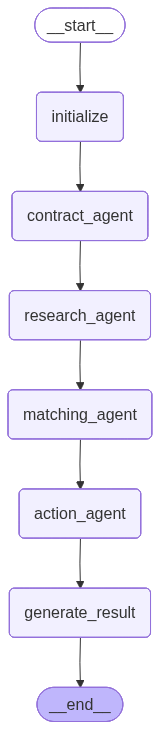

In [10]:
from IPython.display import Image, display

# Display the supervisor's internal graph (which has decorated nodes)
display(Image(supervisor.graph.get_graph(xray=True).draw_mermaid_png()))

## Execute Workflow with Governance Evaluation

In [11]:
# Cell 11A: Setup and Query Definition
test_query = "I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps"

print("="*80)
print("EXECUTING WORKFLOW WITH GOVERNANCE")
print("="*80)
print(f"\nQuery: {test_query}\n")

EXECUTING WORKFLOW WITH GOVERNANCE

Query: I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps



In [12]:
# Cell 11B: Execute Workflow
# Start governance tracking
evaluator.start_run()

try:
    # Execute workflow using supervisor's internal graph (which has decorators)
    result = supervisor.run(
        seller_query=test_query,
        message_id="test_001"
    )
    
    print("\n[SUCCESS] Workflow execution completed")
    
finally:
    # End governance tracking and collect metrics
    evaluator.end_run()


SUPERVISORY AGENT - Workflow Initialization
Seller Query: I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps

Workflow Type: renewal_expiration_awareness
Required Agents: contract, action
Partner Name: Confluent

[DEBUG CONTRACT NODE] Function called
[DEBUG CONTRACT NODE] State keys: ['seller_query', 'contract_file_path', 'partner_name', 'messages', 'message_id', 'workflow_stage', 'required_agents']
[DEBUG CONTRACT NODE] message_id in state: test_001

EXECUTING CONTRACT AGENT
Preloading contract portfolio for partner: Confluent
Contract scope: all files in docs/ beginning with Confluent_IBM
✓ Using cached data for: Confluent_IBM-1.30.2024.docx
✓ Using cached metadata for: Confluent_IBM-1.30.2024.docx
✓ Using cached structured data for: Confluent_IBM-1.30.2024.d

In [13]:
# Cell 11C: Retrieve Metrics
eval_result = evaluator.get_result()
metrics_df = eval_result.to_df()
print(f"[SUCCESS] Metrics retrieved: {metrics_df.shape[0]} rows, {metrics_df.shape[1]} columns")

[SUCCESS] Metrics retrieved: 1 rows, 11 columns


In [14]:
# Cell 11D: Display Generated Response
print("\n" + "="*80)
print("GENERATED RESPONSE")
print("="*80)
print(result['final_result'])


GENERATED RESPONSE
SALES ASSIST TOOL - WORKFLOW COMPLETE

Original Query: I'm a new seller at IBM. I recently got Confluent as a new customer and I want to understand what contracts are coming up for renewal. Are there any contracts that have already expired. Based on the CRM, Contracts and webscraped information can you then put a plan of next steps
Timestamp: 2026-04-28 14:01:37

EXECUTIVE SUMMARY

Partner: Confluent
Maturity Level: Engaged Prospect
Sales Velocity: High

RISK ASSESSMENT:
  Risk Level: High
  Risk Score: 80/100

RECOMMENDED NEXT STEP

DETAILED CONTRACT ANALYSIS WITH REASONING

PRIORITY 1: CRITICAL URGENCY - IMMEDIATE ACTION REQUIRED

CONTRACT: Confluent_IBM-1.30.2025.docx
- Product(s): watsonx
- Value: $250,003.20
- Previous Signers: Unknown
- Status: EXPIRED (87 days ago)
- End Date: 2026-01-31

CRM LINKAGE:
- CRM Status: CONTRACT SIGNED
- Opportunity: "Confluent watsonx ESA"
- Owner: Anand Das
- Stage: Won
- Amount:  $250,000.00 
- Close Date: 1/31/25
- Next Steps:

In [15]:
# Cell 11E: Display Governance Metrics
print("\n" + "="*80)
print("GOVERNANCE METRICS")
print("="*80)
display(metrics_df)


GOVERNANCE METRICS


,message_id,action_agent.latency,contract_agent.latency,generate_result.latency,initialize.latency,matching_agent.latency,message.cost,message.duration,message.input_token_count,message.output_token_count,research_agent.latency
0,5ba91faf7a024204f7c1bd874da5e709,12.4571,27.7876,0.0248,10.5265,83.8158,0.0093,193.2463,10571.0,2586.0,58.5587


In [16]:
# Cell 11F: Display Metrics Summary
print("\n" + "="*80)
print("METRICS SUMMARY")
print("="*80)

# Display full dataframe first
print("\nFull Metrics DataFrame:")
print(f"Columns: {list(metrics_df.columns)}")
print(f"Shape: {metrics_df.shape}")
print()
display(metrics_df)
print()

# Extract and display metrics by category
print("="*80)
print("DETAILED METRICS BREAKDOWN")
print("="*80 + "\n")

if len(metrics_df) > 0:
    row = metrics_df.iloc[0]
    cols = list(metrics_df.columns)
    
    # Latency Metrics
    print("Latency (seconds):")
    latency_cols = [col for col in cols if 'latency' in col.lower()]
    if latency_cols:
        for col in sorted(latency_cols):
            if pd.api.types.is_numeric_dtype(metrics_df[col]):
                value = row[col]
                if pd.notna(value):
                    print(f"  {col}: {value:.4f}s")
    else:
        print("  No latency metrics found")
    print()
    
    # Quality Metrics
    print("Quality Metrics:")
    quality_cols = [col for col in cols if any(metric in col.lower() for metric in 
                   ['context_relevance', 'faithfulness', 'retrieval_precision', 
                    'answer_relevance', 'hallucination'])]
    if quality_cols:
        for col in sorted(quality_cols):
            if pd.api.types.is_numeric_dtype(metrics_df[col]):
                value = row[col]
                if pd.notna(value):
                    print(f"  {col}: {value:.4f}")
    else:
        print("  No quality metrics found")
    print()
    
    # Cost Metrics
    print("Cost:")
    if 'message.cost' in cols and pd.notna(row.get('message.cost')):
        print(f"  Total: ${row['message.cost']:.4f}")
    if 'message.input_token_count' in cols and pd.notna(row.get('message.input_token_count')):
        print(f"  Input tokens: {int(row['message.input_token_count'])}")
    if 'message.output_token_count' in cols and pd.notna(row.get('message.output_token_count')):
        print(f"  Output tokens: {int(row['message.output_token_count'])}")
    if 'message.duration' in cols and pd.notna(row.get('message.duration')):
        print(f"  Total duration: {row['message.duration']:.4f}s")
    print()
    
    # Other Metrics
    other_cols = [c for c in cols if c not in latency_cols + quality_cols + 
                 ['message.cost', 'message.input_token_count', 'message.output_token_count', 
                  'message.duration', 'message_id']]
    if other_cols:
        print("Other Metrics:")
        for col in sorted(other_cols):
            value = row[col]
            if pd.notna(value):
                print(f"  {col}: {value}")
        print()

print("="*80)
print("[SUCCESS] Workflow completed with governance metrics")
print("="*80)


METRICS SUMMARY

Full Metrics DataFrame:
Columns: ['message_id', 'action_agent.latency', 'contract_agent.latency', 'generate_result.latency', 'initialize.latency', 'matching_agent.latency', 'message.cost', 'message.duration', 'message.input_token_count', 'message.output_token_count', 'research_agent.latency']
Shape: (1, 11)



,message_id,action_agent.latency,contract_agent.latency,generate_result.latency,initialize.latency,matching_agent.latency,message.cost,message.duration,message.input_token_count,message.output_token_count,research_agent.latency
0,5ba91faf7a024204f7c1bd874da5e709,12.4571,27.7876,0.0248,10.5265,83.8158,0.0093,193.2463,10571.0,2586.0,58.5587



DETAILED METRICS BREAKDOWN

Latency (seconds):
  action_agent.latency: 12.4571s
  contract_agent.latency: 27.7876s
  generate_result.latency: 0.0248s
  initialize.latency: 10.5265s
  matching_agent.latency: 83.8158s
  research_agent.latency: 58.5587s

Quality Metrics:
  No quality metrics found

Cost:
  Total: $0.0093
  Input tokens: 10571
  Output tokens: 2586
  Total duration: 193.2463s

[SUCCESS] Workflow completed with governance metrics


## Export Results

In [17]:
# Export metrics to CSV
output_file = "sales_agent_governance_results.csv"
metrics_df.to_csv(output_file, index=False)
print(f"[SUCCESS] Metrics exported to {output_file}")

[SUCCESS] Metrics exported to sales_agent_governance_results.csv


## Summary

This notebook demonstrates:
1. **Real-time node-level evaluation** using AgenticEvaluator decorators
2. **LangGraph workflow** with contract and CRM retrieval nodes
3. **Graph visualization** showing the workflow structure
4. **Comprehensive metrics** including faithfulness, context relevance, costs, and latency
5. **Batch processing** with governance tracking for multiple queries

### Key Differences from Batch Evaluation:
- Metrics are computed **during** workflow execution, not after
- Each node can be evaluated independently
- Provides detailed insights into each step of the workflow
- Enables conditional routing based on metric scores